# 02rl · FunnyBird CBM: matched visibility-aware relabeling test

**Report question.** Did positive concept labels attached to invisible parts
cause some of the controlled backwash established for the standard FunnyBird
CBM in notebook 02?

**Population.** Standard CBM versus matched CBM-RLv2, seed 1, epoch 100. This
notebook contains no MCBM and no gamma sweep. `RLv2` means visibility-aware
relabeling, not reinforcement learning.

**Causal scope.** Training/validation images, class labels, architecture,
optimizer, schedule, seed, epoch, and fixed-render evaluation must match. The
only permitted training-record difference is `attribute_label`. If any parity
check fails, later differences are diagnostics rather than causal evidence.


## What this notebook must prove

Notebook 02 already proved the standard-CBM event. This notebook does not ask
whether backwash exists again. It tests one proposed cause.

| Step | Needed fact | Why it is needed |
|---|---|---|
| 1 | reproduce the accepted standard-CBM motivation | prevents RLv2 from replacing the discovery story |
| 2 | define and count the label changes | identifies the manipulated training signal |
| 3 | prove record, configuration, checkpoint, and render parity | makes the comparison causal with respect to labels |
| 4 | verify both models are usable | excludes collapse or failed training |
| 5 | compare the controlled event on identical swaps | primary causal result |
| 6 | count resolved, remaining, and introduced events | distinguishes improvement from merely moving averages |
| 7 | identify which raw score changed | tests the proposed source-suppression mechanism |
| 8 | repeat direction, visibility, exact-value, species, and downstream checks | tests alternative explanations and the remainder |
| 9 | align the standard and RLv2 summaries | states exactly what changed and what did not |

Every result follows: **question → variables/prediction → method → figure →
literal observation → alternative → discriminating test → limited conclusion →
next question**. No result is accepted until its figure is shown in chat.


## The two CBMs and the notation

Both models implement the same computation:

```text
x_i → encoder → h_i
                ├→ learned concept head q_j(h_ij) → raw logit z_ij → p_ij=sigmoid(z_ij)
                └→ class head on the complete h_i → species logits
```

Both use `L_CBM = L_task + beta × L_concept`. The class head reads `h_i`, not
hard concept decisions. Grounding analyses use the post-head raw logit `z`, not
the saved latent slot `h` and not probability `p`.

| Symbol | Meaning |
|---|---|
| `c_standard[i,j]` | original processed 0/1 concept label |
| `v[i,g(j)]` | whether the renderer says the mapped part is visible |
| `c_RLv2[i,j] = c_standard[i,j] × v[i,g(j)]` | visibility-aware concept label |
| `S_orig`, `D_orig` | source and donor concept logits on the original image |
| `S_cf`, `D_cf` | source and donor concept logits after replacement |
| `m_orig = D_orig-S_orig` | donor-minus-source margin before replacement |
| `m_cf = D_cf-S_cf` | final donor-minus-source margin |
| `response_delta = m_cf-m_orig` | donorward movement caused by replacement |

The controlled candidate event remains exactly the notebook-02 definition:

`response_delta > 0 and m_cf < 0`.

RLv2 is predicted to lower `S_cf` most directly. It may raise `D_cf`, but fewer
positive training labels make that less certain. Because RLv2 can also change
`m_orig`, stronger `response_delta` is secondary; the primary endpoint is the
final event on the identical replacement.


## 0 · Accepted standard-CBM evidence that motivated RLv2

The four images below are copied verbatim from the executed notebook 02. They
are not recomputed with the RLv2 model and are not new results.


### Notebook-02 Figure 4 · Controlled standard-CBM backwash predicate

The standard model usually moves toward the inserted donor, but the old source often remains higher. Tail, beak, and eye contain the largest controlled candidate fractions.

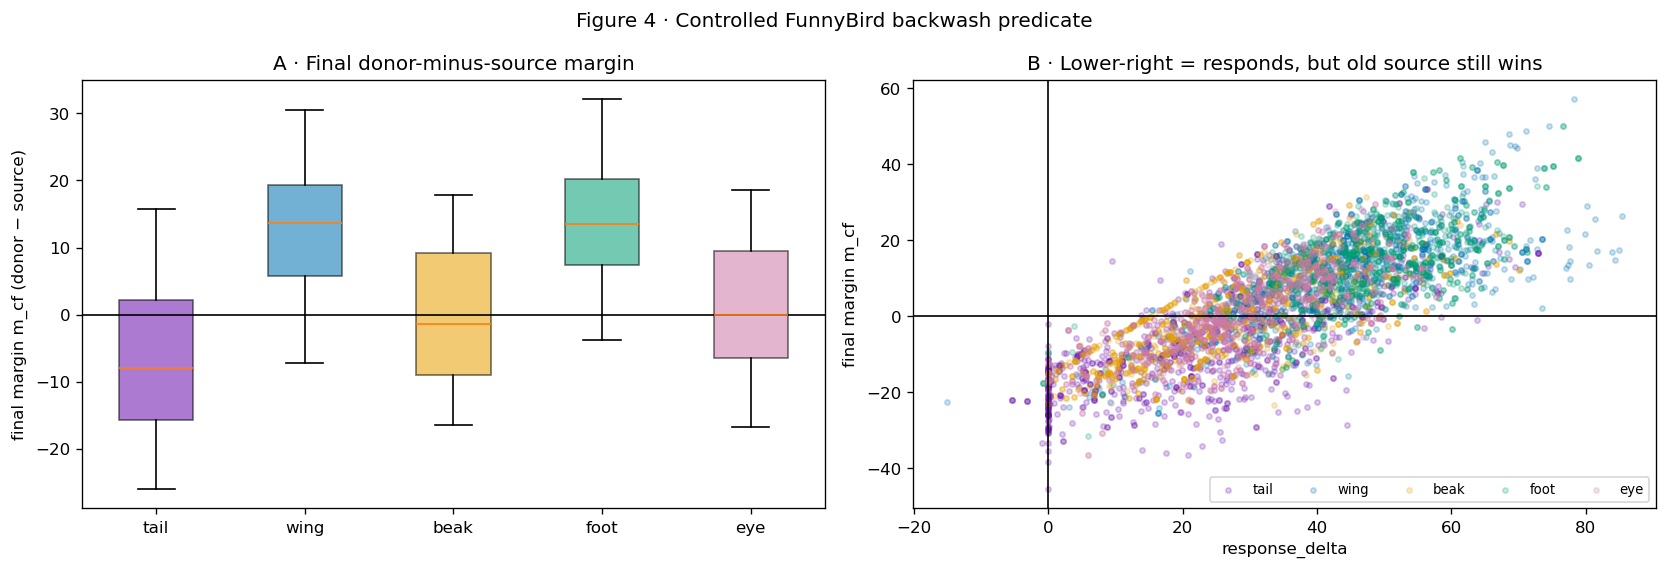


### Notebook-02 Figure 6 · Visibility contributes but is insufficient

Larger inserted masks generally improve the final margin. Clear visibility does not reduce every part's candidate rate to zero, so visibility alone is not a complete explanation.

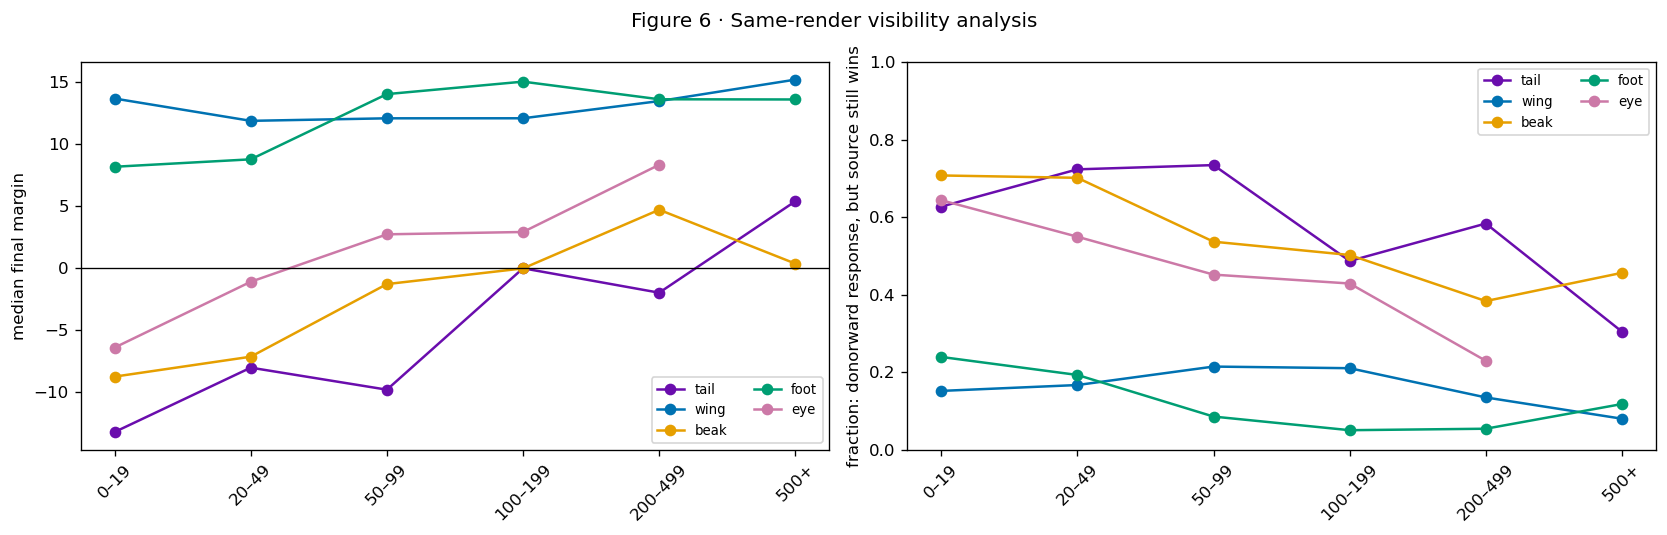


### Notebook-02 Figure 6b · Positive labels can conflict with visible evidence

The original training data contain positive concept labels whose named part is not visible. This is a measured property of the targets, not yet a causal model effect.

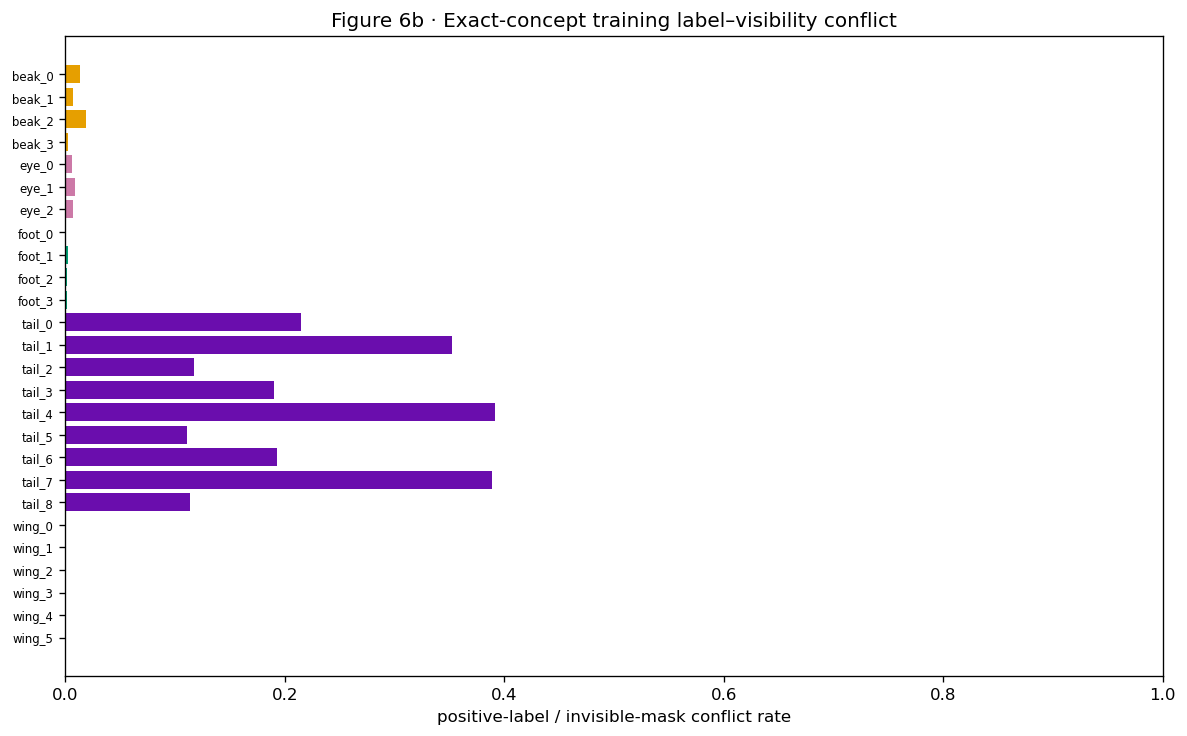


### Notebook-02 Figure 9b · Outcome and proposed contributors in one part order

Tail is high in the controlled outcome, clear-visibility remainder, label conflict, and donor-value error. The four fractions have different denominators and must not be added.

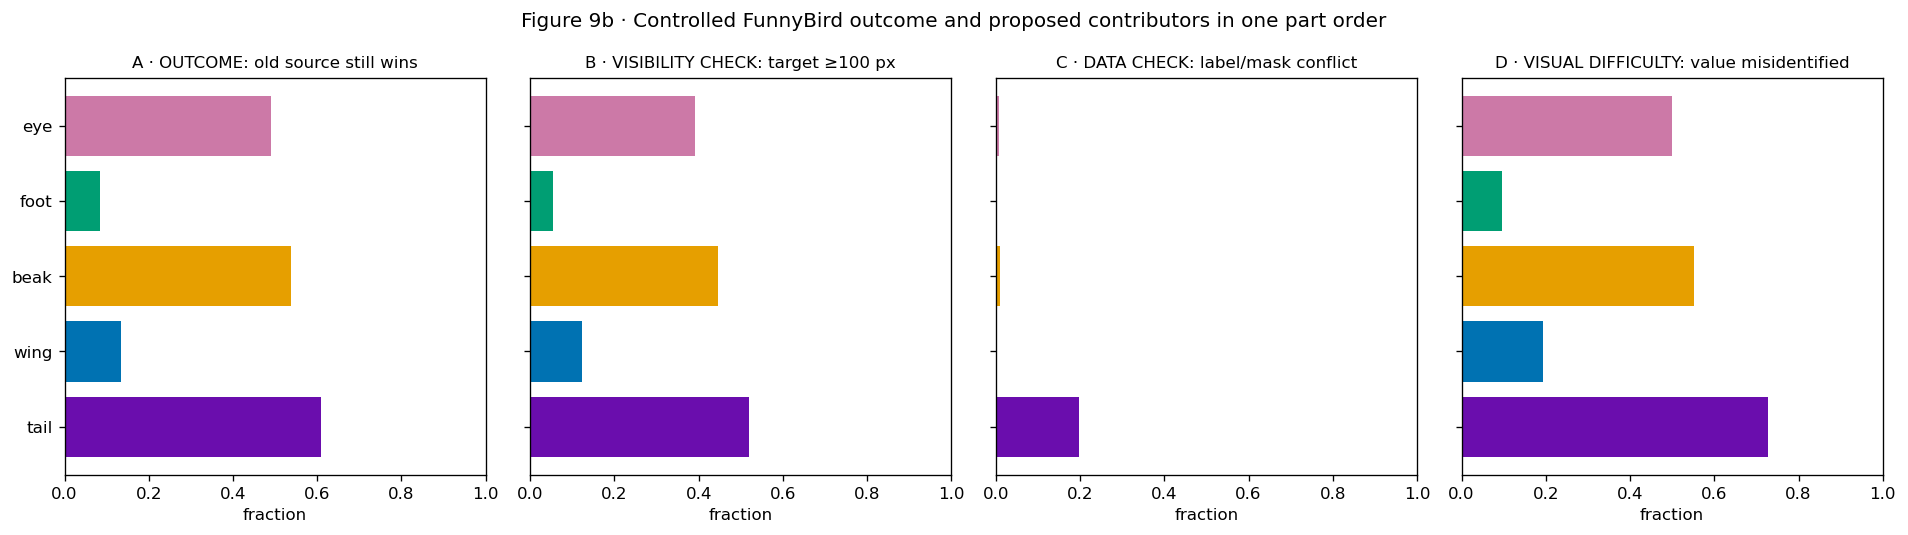


## Predictions fixed before reading RLv2 behavior

1. Tail should show the largest reduction in candidate events because it has
   the largest training-label conflict.
2. Beak and eye may improve modestly.
3. Foot and wing should change little.
4. The most direct mechanism is a lower removed-source score `S_cf`.
5. The final margin `m_cf=D_cf-S_cf` should move right.
6. `response_delta` may not rise by the same amount because RLv2 intentionally
   changes low-visibility original images too.
7. Exact-value and source-species residuals may remain; RLv2 manipulates labels,
   not the number of variants or the unchanged source body.


In [ ]:
# ALT: Load only the matched standard-CBM and CBM-RLv2 fixed-render rows and fail if any render identity differs.
import os, re, json, sys, hashlib, subprocess, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

CURATED = Path(os.environ["CURATED_DATA"])
CWD = Path.cwd()
REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
ORDER = ["tail", "wing", "beak", "foot", "eye"]
COLORS = {"tail":"#6A0DAD", "wing":"#0072B2", "beak":"#E69F00",
          "foot":"#009E73", "eye":"#CC79A7"}
REGIME_COLORS = {"standard":"#0072B2", "RLv2":"#009E73"}
plt.rcParams.update({"figure.dpi":120, "axes.grid":False})
pd.set_option("display.max_rows",250); pd.set_option("display.max_columns",50)

STD_PREFIX="funnybirds-cbm"
RL_PREFIX="funnybirds-cbm-rlv2matched"
EPOCH=100; SEED=1
swap_candidates=[Path(os.environ["FIXED_SWAP_DIR"]) if os.environ.get("FIXED_SWAP_DIR") else None,
                 CURATED/"swap_fixed_v3_matched"]
SWAP_DIR=next((p for p in swap_candidates if p is not None and
               (p/"funnybirds-cbm-s1.csv").exists() and
               (p/"funnybirds-cbm-rlv2matched-s1.csv").exists()),None)
if SWAP_DIR is None:
    raise FileNotFoundError("No validated directory contains the matched CBM fixed-render pair")

STD=pd.read_csv(SWAP_DIR/"funnybirds-cbm-s1.csv")
RL=pd.read_csv(SWAP_DIR/"funnybirds-cbm-rlv2matched-s1.csv")
for frame in [STD,RL]:
    if "response_delta" not in frame:
        frame["response_delta"]=frame.margin-(frame.z_new_orig-frame.z_old_orig)
    frame["candidate"]=(frame.response_delta>0)&(frame.margin<0)
keys=["render_id"]
Q=STD.merge(RL,on=keys,validate="one_to_one",suffixes=("_standard","_rl"))
same_cols=["image_cf_sha256","image_orig_sha256","part","direction","sid_src","sid_donor",
           "var_src","var_donor","li","pixel_count_cf"]
for col in same_cols:
    a,b=f"{col}_standard",f"{col}_rl"
    if not Q[a].equals(Q[b]): raise RuntimeError(f"fixed rows disagree on {col}")
    Q[col]=Q[a]
Q["candidate_standard"]=(Q.response_delta_standard>0)&(Q.margin_standard<0)
Q["candidate_rl"]=(Q.response_delta_rl>0)&(Q.margin_rl<0)
Q["pair_id"]=Q.apply(lambda r:f"{r['part']}:{min(r.sid_src,r.sid_donor)}-{max(r.sid_src,r.sid_donor)}",axis=1)
Q["transition"]=np.select([
    Q.candidate_standard&~Q.candidate_rl,
    Q.candidate_standard&Q.candidate_rl,
    ~Q.candidate_standard&Q.candidate_rl],
    ["resolved","remaining","introduced"],default="never candidate")

FB_ROOT=Path(os.environ.get("FUNNYBIRDS_ROOT",CURATED/"FunnyBirds"))
sys.path.insert(0,str(REPO/"data"/"funnybirds"))
import funnybirds_concepts as fbc
parts=fbc.load_parts(FB_ROOT); CONCEPT_NAMES=fbc.concept_names(parts); SPANS=fbc.group_slices(parts)
CONCEPT_PART={n:p for p,(lo,hi) in SPANS.items() for n in CONCEPT_NAMES[lo:hi]}
print("validated fixed-render root:",SWAP_DIR)
print("paired rows:",len(Q),"parts:",sorted(Q.part.unique()))


## 1 · What training supervision changed?

**Question.** What training supervision changed?

**Variables and prediction.** For every exact concept, count original positive labels and labels changed from 1 to 0 by RLv2. The part-level conflict rate is changed labels divided by original positive labels. If the proposed cause is correctly targeted, tail should receive the largest intervention, followed far behind by beak and eye.

**Method.** Compare the matched training pickle records in their original order, allow only `attribute_label` to differ, and show one changed record per part.

### Figure 1 · What training supervision changed?

**How to read the figure.** Panel A shows the exact-concept conflict fraction. Panel B shows changed record counts by part on a log scale. The example table prints one real changed image/concept record for every part. These are intervention sizes, not behavioral improvements.


In [ ]:
# ALT: Exact and part-level FunnyBird training-label changes plus one concrete changed record for each part.
import yaml
CFG=REPO/"external"/"minimal_cbm"/"configs"/"funnybirds"
std_cfg=yaml.safe_load((CFG/f"{STD_PREFIX}.yaml").read_text())
rl_cfg=yaml.safe_load((CFG/f"{RL_PREFIX}.yaml").read_text())
STD_PKLS=Path(std_cfg["data"]["pkls_dir"]); RL_PKLS=Path(rl_cfg["data"]["pkls_dir"])
with open(STD_PKLS/"train.pkl","rb") as f: std_train=pickle.load(f)
with open(RL_PKLS/"train.pkl","rb") as f: rl_train=pickle.load(f)
if len(std_train)!=len(rl_train): raise RuntimeError("matched train lengths differ")

positive=np.zeros(len(CONCEPT_NAMES),dtype=int); changed=np.zeros(len(CONCEPT_NAMES),dtype=int)
examples={}
for idx,(a,b) in enumerate(zip(std_train,rl_train)):
    ca=np.asarray(a["attribute_label"]); cb=np.asarray(b["attribute_label"])
    positive+=(ca==1); changed+=((ca==1)&(cb==0))
    for j in np.flatnonzero((ca==1)&(cb==0)):
        part=CONCEPT_PART[CONCEPT_NAMES[j]]
        if part not in examples:
            examples[part]={"record_index":idx,"image":a.get("image",a.get("img_path")),
                            "concept":CONCEPT_NAMES[j],"standard_label":int(ca[j]),"RLv2_label":int(cb[j])}
EXACT_CONFLICT=pd.DataFrame({"concept":CONCEPT_NAMES,"part":[CONCEPT_PART[n] for n in CONCEPT_NAMES],
                             "n_positive":positive,"n_changed":changed})
EXACT_CONFLICT["conflict_rate"]=EXACT_CONFLICT.n_changed/EXACT_CONFLICT.n_positive.replace(0,np.nan)
PART_CONFLICT=EXACT_CONFLICT.groupby("part").agg(n_positive=("n_positive","sum"),n_changed=("n_changed","sum")).reindex(ORDER)
PART_CONFLICT["conflict_rate"]=PART_CONFLICT.n_changed/PART_CONFLICT.n_positive

fig,axes=plt.subplots(1,2,figsize=(14,6))
d=EXACT_CONFLICT.sort_values(["part","concept"]); y=np.arange(len(d))
axes[0].barh(y,d.conflict_rate,color=d.part.map(COLORS)); axes[0].set_yticks(y,d.concept,fontsize=7)
axes[0].invert_yaxis(); axes[0].set_xlim(0,1); axes[0].set_xlabel("changed / original-positive labels")
axes[0].set_title("A · Exact-concept label intervention")
axes[1].bar(PART_CONFLICT.index,PART_CONFLICT.n_changed,color=[COLORS[p] for p in PART_CONFLICT.index])
axes[1].set_yscale("log"); axes[1].set_ylabel("changed training records (log scale)")
axes[1].set_title("B · Intervention size by part")
for x,(p,row) in enumerate(PART_CONFLICT.iterrows()): axes[1].text(x,row.n_changed*1.15,f"{row.n_changed:,}",ha="center",fontsize=8)
fig.suptitle("Figure 1 · What RLv2 changed in the matched training labels")
plt.tight_layout();plt.show();display(EXACT_CONFLICT.round(3));display(PART_CONFLICT.round(3));display(pd.DataFrame(examples).T)


### Review record for Figure 1

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did anything besides the concept labels differ between training regimes?


## 2 · Is RLv2 the only training difference?

**Question.** Is RLv2 the only training difference?

**Variables and prediction.** Compare every nested configuration setting and every non-label pickle-record field. The allowed configuration difference is only `data.pkls_dir`; within records, only `attribute_label` may differ. A causal label claim requires identical ordered images, record IDs, class labels, train/validation membership, and all model/training settings.

**Method.** Fail closed on the first unexpected difference and print explicit train/validation denominators.

### Figure 2 · Is RLv2 the only training difference?

**How to read the figure.** The table has one row for configuration parity and one row for each split. Every Boolean must be true. This is an audit table, not a model-performance result.


In [ ]:
# ALT: Fail-closed standard-CBM versus CBM-RLv2 configuration and record-parity table.
def semantic_differences(a,b,path=()):
    if isinstance(a,dict) and isinstance(b,dict):
        out=[]
        for k in sorted(set(a)|set(b)):
            if k not in a or k not in b: out.append(path+(k,))
            else: out.extend(semantic_differences(a[k],b[k],path+(k,)))
        return out
    if isinstance(a,list) and isinstance(b,list):
        if len(a)!=len(b): return [path]
        return [q for i,(x,y) in enumerate(zip(a,b)) for q in semantic_differences(x,y,path+(i,))]
    return [] if a==b else [path]

cfg_diffs=semantic_differences(std_cfg,rl_cfg)
if cfg_diffs!=[("data","pkls_dir")]: raise RuntimeError(f"unexpected config differences: {cfg_diffs}")
def value_equal(x,y):
    try:return bool(np.array_equal(np.asarray(x),np.asarray(y)))
    except:return x==y
def identity(r): return (str(r.get("image",r.get("img_path"))).replace("\\","/"),int(r["class_label"]),r.get("id"))
parity=[]
for split in ["train","test"]:
    with open(STD_PKLS/f"{split}.pkl","rb") as f:a=pickle.load(f)
    with open(RL_PKLS/f"{split}.pkl","rb") as f:b=pickle.load(f)
    same_len=len(a)==len(b); same_ids=same_len and [identity(r) for r in a]==[identity(r) for r in b]
    bad=[]
    if same_len:
        for i,(ra,rb) in enumerate(zip(a,b)):
            keys=set(ra)|set(rb)
            diff=[k for k in keys if k!="attribute_label" and not value_equal(ra.get(k),rb.get(k))]
            if diff: bad.append((i,diff));break
    parity.append({"check":split,"n_standard":len(a),"n_RLv2":len(b),"same_ordered_image_class_id":same_ids,
                   "same_all_non_label_fields":same_len and not bad,"first_unexpected_difference":bad[:1]})
PARITY=pd.DataFrame([{"check":"configuration","n_standard":np.nan,"n_RLv2":np.nan,
                      "same_ordered_image_class_id":True,"same_all_non_label_fields":cfg_diffs==[("data","pkls_dir")],
                      "first_unexpected_difference":str(cfg_diffs)}]+parity)
display(PARITY)
if not PARITY[["same_ordered_image_class_id","same_all_non_label_fields"]].to_numpy().all():
    raise RuntimeError("training/configuration parity failed")
print("ACCEPTED FOR matched training/configuration parity")


### Review record for Figure 2

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Were both epoch-100 models usable rather than collapsed or broken?


## 3 · Did both trainings produce usable CBMs?

**Question.** Did both trainings produce usable CBMs?

**Variables and prediction.** For every exact concept and each regime, calculate raw-z spread, label separation against that regime's saved target, balanced accuracy, and positive recall. Also report species-task accuracy. Both models must have non-collapsed outputs and above-chance health; otherwise a change in swap behavior could reflect failed training.

**Method.** Replay each saved learned concept head on its saved latent slots and verify that sigmoid of the recovered raw logits reproduces the saved probabilities.

### Figure 3 · Did both trainings produce usable CBMs?

**How to read the figure.** Rows are exact concepts and columns are the same four health measures as notebook 02. Standard and RLv2 are shown separately. These are health checks, not grounding evidence.


In [ ]:
# ALT: Standard and RLv2 exact-concept raw-score spread, label separation, balanced accuracy, and positive recall.
import torch
sys.path.insert(0,str(REPO/"analysis"))
from minimal_cbm_scores import concept_logits_from_saved_latent,validate_saved_probabilities
def balanced_accuracy(y,p):
    y=np.asarray(y).astype(int);p=np.asarray(p).astype(int)
    return np.nanmean([(p[y==1]==1).mean() if (y==1).any() else np.nan,
                       (p[y==0]==0).mean() if (y==0).any() else np.nan])
PRED_DATA={};health=[];health_summary=[]
for regime,prefix in [("standard",STD_PREFIX),("RLv2",RL_PREFIX)]:
    pred_path=REPO/"external"/"minimal_cbm"/"results"/prefix/str(SEED)/"predictions"/f"epoch_{EPOCH}.pth"
    model_path=REPO/"external"/"minimal_cbm"/"results"/prefix/str(SEED)/"models"/f"epoch_{EPOCH}.pt"
    d=torch.load(pred_path,map_location="cpu",weights_only=False)
    c=np.asarray(d["c"]).reshape(len(d["c"]),-1); y=np.asarray(d["y"]).reshape(-1).astype(int)
    zt=concept_logits_from_saved_latent(d["z"],model_path,c.shape[1]); err=validate_saved_probabilities(zt,d["c_preds"])
    z=zt.numpy(); PRED_DATA[regime]={"dump":d,"z":z,"c":c,"y":y,"pred_path":pred_path,"model_path":model_path}
    yp=np.asarray(d["y_preds"]);yp=yp.reshape(len(yp),-1)
    health_summary.append({"regime":regime,"images":len(y),"task_accuracy":(yp.argmax(1)==y).mean(),"head_replay_error":err})
    for j,name in enumerate(CONCEPT_NAMES):
        zz=z[:,j];cc=c[:,j].astype(int);pred=(zz>0).astype(int)
        health.append({"regime":regime,"concept":name,"part":CONCEPT_PART[name],
          "spread":np.quantile(zz,.95)-np.quantile(zz,.05),
          "label_separation":np.median(zz[cc==1])-np.median(zz[cc==0]),
          "balanced_accuracy":balanced_accuracy(cc,pred),"positive_recall":pred[cc==1].mean()})
HEALTH=pd.DataFrame(health);display(pd.DataFrame(health_summary).round(5));display(HEALTH.round(3))
fig,axes=plt.subplots(2,4,figsize=(16,12),sharey="row")
metrics=["spread","label_separation","balanced_accuracy","positive_recall"]
for r,regime in enumerate(["standard","RLv2"]):
    d=HEALTH[HEALTH.regime==regime].sort_values(["part","concept"]);y=np.arange(len(d))
    for ax,m in zip(axes[r],metrics):
        ax.scatter(d[m],y,c=d.part.map(COLORS),s=22);ax.set_title(f"{regime}: {m.replace('_',' ')}")
        if m=="label_separation":ax.axvline(0,color="black",lw=.8)
        if m in ["balanced_accuracy","positive_recall"]:ax.axvline(.5,color="gray",ls="--")
    axes[r,0].set_yticks(y,d.concept,fontsize=7);axes[r,0].invert_yaxis()
fig.suptitle("Figure 3 · Exact-concept health for standard CBM and matched CBM-RLv2")
plt.tight_layout(rect=[0,0,1,.98]);plt.show()


### Review record for Figure 3

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Were the two models evaluated on exactly the same valid rendered images?


## 4 · Are the fixed-render comparisons pixel-identical?

**Question.** Are the fixed-render comparisons pixel-identical?

**Variables and prediction.** Check one-to-one render IDs, original hashes, counterfactual hashes, part, direction, source/donor identities, exact values, and visible-pixel counts. Every identity must match before a score difference is attributed to training labels.

**Method.** Display the accepted renderer preflight and print the full paired-image audit.

### Figure 4 · Are the fixed-render comparisons pixel-identical?

**How to read the figure.** The image shows original, replacement, deletion, and part maps for all parts. The table reports 5,000 paired rows and Boolean identity checks. This is an intervention audit, not a behavioral result.


In [ ]:
# ALT: Validated all-part FunnyBird renderer preflight plus identical-render audit for the standard/RLv2 pair.
audit=pd.DataFrame([{"paired_rows":len(Q),"unique_render_ids":Q.render_id.nunique(),
 "unique_counterfactual_hashes":Q.image_cf_sha256_standard.nunique(),
 "all_counterfactual_hashes_match":(Q.image_cf_sha256_standard==Q.image_cf_sha256_rl).all(),
 "all_original_hashes_match":(Q.image_orig_sha256_standard==Q.image_orig_sha256_rl).all(),
 "parts":",".join(sorted(Q.part.unique())),"directions":",".join(sorted(Q.direction.unique()))}])
display(audit)
if len(Q)!=5000 or not audit[["all_counterfactual_hashes_match","all_original_hashes_match"]].to_numpy().all():
    raise RuntimeError("fixed-render parity failed")
preflight=SWAP_DIR/"renderer_preflight"/"renderer_semantic_preflight.png"
if not preflight.exists():raise FileNotFoundError(preflight)
fig,ax=plt.subplots(figsize=(15,4));ax.imshow(Image.open(preflight).convert("RGB"));ax.axis("off")
ax.set_title("Figure 4 · Accepted renderer semantic preflight shared by standard and RLv2")
plt.tight_layout();plt.show()


### Review record for Figure 4

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did changing only the labels reduce the controlled candidate event?


## 5 · Did RLv2 reduce controlled backwash on identical swaps?

**Question.** Did RLv2 reduce controlled backwash on identical swaps?

**Variables and prediction.** For each part and regime, plot final margin `m_cf` and the rate satisfying both `response_delta>0` and `m_cf<0`. Tail should improve most; beak and eye may improve modestly; foot and wing should remain similar.

**Method.** Use the exact same 1,000 swaps per part and pair rows by render ID and image hash.

### Figure 5 · Did RLv2 reduce controlled backwash on identical swaps?

**How to read the figure.** Panel A shows final-margin distributions; values right of zero favor the donor. Panel B shows the complete candidate rate. A lower RLv2 bar means fewer identical swaps responded to donor pixels yet still preferred the removed source.


In [ ]:
# ALT: Paired standard-CBM and CBM-RLv2 final margins and controlled candidate-event rates for every part.
fig,axes=plt.subplots(1,2,figsize=(15,5))
positions=[];values=[];colors=[];ticks=[];labels=[];pos=1
for part in ORDER:
    for regime,suffix in [("standard","standard"),("RLv2","rl")]:
        positions.append(pos);values.append(Q.loc[Q.part==part,f"margin_{suffix}"]);colors.append(REGIME_COLORS[regime]);pos+=1
    ticks.append(pos-1.5);labels.append(part);pos+=.5
bp=axes[0].boxplot(values,positions=positions,widths=.75,showfliers=False,whis=(5,95),patch_artist=True)
for b,c in zip(bp["boxes"],colors):b.set_facecolor(c);b.set_alpha(.6)
axes[0].axhline(0,color="black",lw=.8);axes[0].set_xticks(ticks,labels);axes[0].set_ylabel("final margin m_cf")
axes[0].set_title("A · Final donor-minus-source margin")
rates=[]
for part in ORDER:
    d=Q[Q.part==part];rates.append({"part":part,"standard":d.candidate_standard.mean(),"RLv2":d.candidate_rl.mean(),"n":len(d)})
PRIMARY=pd.DataFrame(rates).set_index("part").reindex(ORDER);x=np.arange(len(ORDER));w=.36
axes[1].bar(x-w/2,PRIMARY.standard,w,color=REGIME_COLORS["standard"],label="standard")
axes[1].bar(x+w/2,PRIMARY.RLv2,w,color=REGIME_COLORS["RLv2"],label="RLv2")
axes[1].set_xticks(x,ORDER);axes[1].set_ylim(0,1);axes[1].set_ylabel("fraction: response_delta>0 and m_cf<0")
axes[1].set_title("B · Controlled candidate rate");axes[1].legend()
fig.suptitle("Figure 5 · Primary matched CBM-RLv2 result")
plt.tight_layout();plt.show();display(PRIMARY.round(3))


### Review record for Figure 5

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Which standard candidate events were resolved, remained, or were newly introduced?


## 6 · Which individual swap outcomes changed?

**Question.** Which individual swap outcomes changed?

**Variables and prediction.** Classify every paired row as resolved, remaining, introduced, or never a candidate using the unchanged candidate predicate. A useful intervention should resolve more standard events than it introduces, especially for tail.

**Method.** Count transitions on identical render IDs and report both all-row rates and the conditional resolution rate among standard candidates.

### Figure 6 · Which individual swap outcomes changed?

**How to read the figure.** Each bar partitions all swaps for a part into four mutually exclusive states. `Resolved` means standard was a candidate and RLv2 was not; `introduced` is the reverse. The table prints the exact denominators.


In [ ]:
# ALT: Resolved, remaining, introduced, and never-candidate transitions for every identical FunnyBird swap.
cats=["resolved","remaining","introduced","never candidate"]
TRANS=(Q.groupby(["part","transition"]).size().unstack(fill_value=0).reindex(index=ORDER,columns=cats,fill_value=0))
TRANS_RATE=TRANS.div(TRANS.sum(1),axis=0)
TRANS["standard_candidates"]=TRANS.resolved+TRANS.remaining
TRANS["resolution_rate_among_standard_candidates"]=TRANS.resolved/TRANS.standard_candidates.replace(0,np.nan)
TRANS["net_candidate_change"]=TRANS.introduced-TRANS.resolved
fig,ax=plt.subplots(figsize=(10,5));left=np.zeros(len(ORDER));palette={"resolved":"#009E73","remaining":"#D55E00","introduced":"#CC79A7","never candidate":"#BBBBBB"}
for c in cats:
    ax.barh(ORDER,TRANS_RATE[c],left=left,label=c,color=palette[c]);left+=TRANS_RATE[c].to_numpy()
ax.set_xlim(0,1);ax.set_xlabel("fraction of identical swaps");ax.set_title("Figure 6 · Standard-to-RLv2 event transitions")
ax.legend(ncol=4,fontsize=8);plt.tight_layout();plt.show();display(TRANS)


### Review record for Figure 6

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did RLv2 work by suppressing the removed source, raising the donor, or both?


## 7 · Which raw concept score changed?

**Question.** Which raw concept score changed?

**Variables and prediction.** For every paired swap compute `ΔD_cf=D_cf_RLv2-D_cf_standard`, `ΔS_cf=S_cf_RLv2-S_cf_standard`, and `Δm_cf=m_cf_RLv2-m_cf_standard`. The proposed mechanism predicts a negative `ΔS_cf` and positive `Δm_cf`, strongest for tail. `ΔD_cf` is less certain.

**Method.** Average paired changes by part and retain the row-level distributions in the table.

### Figure 7 · Which raw concept score changed?

**How to read the figure.** Negative removed-source change means RLv2 turned off the concept that was removed. Positive donor change means it strengthened the inserted concept. Positive margin change means the donor gained relative to the source.


In [ ]:
# ALT: Paired changes in inserted-donor score, removed-source score, final margin, and response delta.
MECH_ROWS=[]
for part,d in Q.groupby("part"):
    MECH_ROWS.append({"part":part,"delta_donor_cf":(d.z_new_rl-d.z_new_standard).mean(),
      "delta_source_cf":(d.z_old_rl-d.z_old_standard).mean(),
      "delta_final_margin":(d.margin_rl-d.margin_standard).mean(),
      "delta_response":(d.response_delta_rl-d.response_delta_standard).mean()})
MECH=pd.DataFrame(MECH_ROWS).set_index("part").reindex(ORDER);x=np.arange(len(ORDER));w=.22
fig,ax=plt.subplots(figsize=(11,5));ax.bar(x-1.5*w,MECH.delta_donor_cf,w,label="Δ donor score D_cf",color="#E69F00")
ax.bar(x-.5*w,MECH.delta_source_cf,w,label="Δ removed-source score S_cf",color="#CC79A7")
ax.bar(x+.5*w,MECH.delta_final_margin,w,label="Δ final margin",color="#009E73")
ax.bar(x+1.5*w,MECH.delta_response,w,label="Δ response_delta",color="#0072B2")
ax.axhline(0,color="black",lw=.8);ax.set_xticks(x,ORDER);ax.set_ylabel("RLv2 − standard raw-logit units")
ax.set_title("Figure 7 · Paired score mechanism");ax.legend(ncol=2);plt.tight_layout();plt.show();display(MECH.round(3))


### Review record for Figure 7

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did RLv2 change the complete original-to-swap response, or mainly the final preference?


## 8 · Did original-to-swap donorward movement change?

**Question.** Did original-to-swap donorward movement change?

**Variables and prediction.** Compare standard and RLv2 `response_delta=m_cf-m_orig` distributions and positive-response rates. RLv2 may strengthen donorward movement, but this is secondary because the original-image margin is also intentionally changed.

**Method.** Use identical rows and show every part.

### Figure 8 · Did original-to-swap donorward movement change?

**How to read the figure.** The boxes show response_delta; above zero means the replacement moved the comparison toward the donor. The bars show the fraction above zero. This does not by itself say whether the donor finishes above the source.


In [ ]:
# ALT: Standard and RLv2 response-delta distributions and positive donor-response rates.
fig,axes=plt.subplots(1,2,figsize=(15,5));positions=[];values=[];colors=[];ticks=[];pos=1
for part in ORDER:
    for regime,suffix in [("standard","standard"),("RLv2","rl")]:
        positions.append(pos);values.append(Q.loc[Q.part==part,f"response_delta_{suffix}"]);colors.append(REGIME_COLORS[regime]);pos+=1
    ticks.append(pos-1.5);pos+=.5
bp=axes[0].boxplot(values,positions=positions,widths=.75,showfliers=False,whis=(5,95),patch_artist=True)
for b,c in zip(bp["boxes"],colors):b.set_facecolor(c);b.set_alpha(.6)
axes[0].axhline(0,color="black",lw=.8);axes[0].set_xticks(ticks,ORDER);axes[0].set_ylabel("response_delta")
rates=[]
for part,d in Q.groupby("part"):
    rates.append({"part":part,"standard":(d.response_delta_standard>0).mean(),"RLv2":(d.response_delta_rl>0).mean()})
RESPONSE=pd.DataFrame(rates).set_index("part").reindex(ORDER);x=np.arange(len(ORDER));w=.36
axes[1].bar(x-w/2,RESPONSE.standard,w,color=REGIME_COLORS["standard"],label="standard")
axes[1].bar(x+w/2,RESPONSE.RLv2,w,color=REGIME_COLORS["RLv2"],label="RLv2")
axes[1].set_xticks(x,ORDER);axes[1].set_ylim(0,1);axes[1].set_ylabel("fraction response_delta>0");axes[1].legend()
fig.suptitle("Figure 8 · Original-to-swap response under each label regime")
plt.tight_layout();plt.show();display(RESPONSE.round(3))


### Review record for Figure 8

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Does the primary result hold in both replacement directions?


## 9 · Could one swap direction create the RLv2 result?

**Question.** Could one swap direction create the RLv2 result?

**Variables and prediction.** Calculate the unchanged candidate predicate separately for forward and backward replacements under each regime. A real part-level label effect should not depend entirely on one arbitrary direction.

**Method.** Keep direction and regime separate and print 500-row denominators.

### Figure 9 · Could one swap direction create the RLv2 result?

**How to read the figure.** Circles and squares distinguish standard and RLv2; solid and dashed lines distinguish forward and backward swaps. Lower candidate rates are better.


In [ ]:
# ALT: Forward and backward controlled candidate-event rates for standard CBM and matched CBM-RLv2.
rows=[]
for (part,direction),d in Q.groupby(["part","direction"]):
    rows.append({"part":part,"direction":direction,"n":len(d),"standard":d.candidate_standard.mean(),"RLv2":d.candidate_rl.mean()})
DIRECTION=pd.DataFrame(rows);fig,ax=plt.subplots(figsize=(10,5))
for regime,marker in [("standard","o"),("RLv2","s")]:
    for direction,ls in [("fwd","-"),("bwd","--")]:
        d=DIRECTION[DIRECTION.direction==direction].set_index("part").reindex(ORDER)
        ax.plot(ORDER,d[regime],marker=marker,ls=ls,color=REGIME_COLORS[regime],label=f"{regime} {direction}")
ax.set_ylim(0,1);ax.set_ylabel("candidate-event fraction");ax.set_title("Figure 9 · Direction-specific controlled candidate rates")
ax.legend(ncol=2);plt.tight_layout();plt.show();display(DIRECTION.round(3))


### Review record for Figure 9

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Is any improvement confined to swaps where the inserted part has little or no visible area?


## 10 · How does exact inserted-part visibility change the RLv2 result?

**Question.** How does exact inserted-part visibility change the RLv2 result?

**Variables and prediction.** Within the same declared pixel-count bins as notebook 02, compare standard and RLv2 candidate rates. If RLv2 only changes zero-pixel cases, it did not improve recognition of visible donor evidence. Improvement among clearly visible rows supports a broader label-training effect.

**Method.** Use exact counterfactual part-map pixel counts and print row denominators for every bin.

### Figure 10 · How does exact inserted-part visibility change the RLv2 result?

**How to read the figure.** Each panel is one part. The x-axis is visible inserted-part pixels and the y-axis is the complete candidate rate. Standard and RLv2 share the same rows in every bin.


In [ ]:
# ALT: Per-part standard/RLv2 candidate rates across exact swapped-part visibility bins.
bins=[0,20,50,100,200,500,np.inf];labels=["0–19","20–49","50–99","100–199","200–499","500+"]
W=Q.copy();W["visibility_bin"]=pd.cut(W.pixel_count_cf,bins=bins,labels=labels,right=False)
rows=[]
for (part,v),d in W.groupby(["part","visibility_bin"],observed=True):
    rows.append({"part":part,"visibility_bin":v,"n":len(d),"standard":d.candidate_standard.mean(),"RLv2":d.candidate_rl.mean()})
VIS=pd.DataFrame(rows);fig,axes=plt.subplots(1,5,figsize=(20,4),sharey=True)
for ax,part in zip(axes,ORDER):
    d=VIS[VIS.part==part].set_index("visibility_bin").reindex(labels)
    ax.plot(labels,d.standard,"o-",color=REGIME_COLORS["standard"],label="standard")
    ax.plot(labels,d.RLv2,"s-",color=REGIME_COLORS["RLv2"],label="RLv2")
    ax.set_title(part);ax.tick_params(axis="x",rotation=60);ax.set_ylim(0,1)
axes[0].set_ylabel("candidate-event fraction");axes[-1].legend()
fig.suptitle("Figure 10 · Matched RLv2 effect across exact visibility bins")
plt.tight_layout(rect=[0,0,1,.95]);plt.show();display(VIS.round(3))


### Review record for Figure 10

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did RLv2 improve exact donor-value recognition, or do particular variants remain difficult?


## 11 · Did exact inserted-value recognition improve?

**Question.** Did exact inserted-value recognition improve?

**Variables and prediction.** For every part and regime, compare the inserted donor value with the highest post-swap raw concept logit. If RLv2 repairs broad label conflict but not visual-value difficulty, tail recognition may improve while particular rows remain poor.

**Method.** Display all exact values in two aligned rows: standard and RLv2.

### Figure 11 · Did exact inserted-value recognition improve?

**How to read the figure.** Each heatmap row is the inserted value and each column is the highest-scoring value. A brighter diagonal means better exact donor recognition. The title prints the full diagonal rate.


In [ ]:
# ALT: All-part exact donor-value confusion matrices for standard CBM and matched CBM-RLv2.
def concept_columns(frame,part):
    return sorted([c for c in frame if c.startswith(f"z_cf_{part}_")],key=lambda x:int(x.rsplit("_",1)[1]))
VALUE_ROWS=[];DIAG={}
fig,axes=plt.subplots(2,5,figsize=(18,7))
for r,(regime,frame) in enumerate([("standard",STD),("RLv2",RL)]):
    for c,part in enumerate(ORDER):
        d=frame[frame.part==part];cols=concept_columns(d,part);pred=d[cols].to_numpy().argmax(1);donor=d.var_donor.astype(int).to_numpy()
        n=len(cols);M=np.zeros((n,n))
        for a,b in zip(donor,pred):M[a,b]+=1
        M=M/np.maximum(M.sum(1,keepdims=True),1);DIAG[(regime,part)]=(pred==donor).mean()
        axes[r,c].imshow(M,cmap="magma",vmin=0,vmax=1);axes[r,c].set_title(f"{part} · {regime}\ndiagonal={DIAG[(regime,part)]:.2f}")
        axes[r,c].set_xlabel("highest-scoring value");
        if c==0:axes[r,c].set_ylabel("inserted value")
        for value,g in d.assign(pred=pred).groupby("var_donor"):
            VALUE_ROWS.append({"regime":regime,"part":part,"donor_value":int(value),"n":len(g),
              "recognition_rate":(g.pred==g.var_donor).mean(),"candidate_rate":g.candidate.mean()})
fig.suptitle("Figure 11 · Exact donor-value recognition before and after RLv2")
plt.tight_layout(rect=[0,0,1,.96]);plt.show();VALUE=pd.DataFrame(VALUE_ROWS);display(VALUE.round(3))


### Review record for Figure 11

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** After exact values, direction, and visibility are controlled, does source species still organize the margin?


## 12 · Does source species still organize the remaining margin?

**Question.** Does source species still organize the remaining margin?

**Variables and prediction.** For each regime, subtract the mean margin within `(part, source value, donor value, direction, visibility bin)` and average the residual by source species. If RLv2 removes label conflict but not unchanged-body context, species residual spread should remain even if it becomes smaller for tail.

**Method.** Require at least five rows per displayed source-species estimate and use identical control strata.

### Figure 12 · Does source species still organize the remaining margin?

**How to read the figure.** Each panel is a part. Source species are ordered by the standard residual; blue is standard and green is RLv2 for the same species. Zero means that species matches its controlled-stratum average.


In [ ]:
# ALT: Matched source-species margin residuals after exact value, direction, and visibility controls.
R=Q.copy();R["vis_bin"]=pd.cut(R.pixel_count_cf,[-1,19,49,99,199,499,np.inf],labels=False)
SPECIES_TABLES={};spread=[]
for regime,suffix in [("standard","standard"),("RLv2","rl")]:
    margin=f"margin_{suffix}";d=R.copy();d["expected"]=d.groupby(["part","var_src","var_donor","direction","vis_bin"])[margin].transform("mean")
    d["residual"]=d[margin]-d.expected
    g=d.groupby(["part","sid_src"]).agg(n=("residual","size"),residual=("residual","mean")).reset_index().query("n>=5")
    SPECIES_TABLES[regime]=g
    for part,x in g.groupby("part"):spread.append({"regime":regime,"part":part,"species":len(x),"residual_sd":x.residual.std()})
SPECIES_SPREAD=pd.DataFrame(spread)
fig,axes=plt.subplots(1,5,figsize=(20,4),sharey=True)
for ax,part in zip(axes,ORDER):
    a=SPECIES_TABLES["standard"].query("part==@part").set_index("sid_src").residual.sort_values()
    b=SPECIES_TABLES["RLv2"].query("part==@part").set_index("sid_src").residual.reindex(a.index)
    x=np.arange(len(a));ax.scatter(x,a,s=16,color=REGIME_COLORS["standard"],label="standard")
    ax.scatter(x,b,s=16,color=REGIME_COLORS["RLv2"],label="RLv2");ax.axhline(0,color="black",lw=.8);ax.set_title(part)
axes[0].set_ylabel("mean residual final margin");axes[-1].legend()
fig.suptitle("Figure 12 · Source-species residual after exact value, direction, and visibility controls")
plt.tight_layout(rect=[0,0,1,.94]);plt.show();display(SPECIES_SPREAD.pivot(index="part",columns="regime",values="residual_sd").reindex(ORDER).round(3))


### Review record for Figure 12

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did RLv2 reduce species information in the learned concept representation?


## 13 · Did species decodability change inside the concept vector?

**Question.** Did species decodability change inside the concept vector?

**Variables and prediction.** For each regime, train the same held-out diagnostic classifier on known labels `c` and learned raw logits `z`, using the same image split. If RLv2 reduces contextual coding, raw-z species accuracy may decrease most for tail. This remains a representation diagnostic, not grounding evidence.

**Method.** Use one fixed stratified 70/30 split and identical logistic-regression settings.

### Figure 13 · Did species decodability change inside the concept vector?

**How to read the figure.** Each panel is one regime. Grey bars use known labels and colored bars use learned raw z. Bar height is diagnostic held-out species accuracy, not the saved CBM's task accuracy.


In [ ]:
# ALT: Matched diagnostic species decoders using known labels and learned raw logits for standard and RLv2 CBMs.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
probe=[]
for regime in ["standard","RLv2"]:
    z=PRED_DATA[regime]["z"];c=PRED_DATA[regime]["c"];y=PRED_DATA[regime]["y"]
    idx=np.arange(len(y));tr,te=train_test_split(idx,test_size=.30,random_state=20260803,stratify=y)
    blocks={"complete":np.arange(z.shape[1])};blocks.update({p:np.arange(lo,hi) for p,(lo,hi) in SPANS.items()})
    for block,cols in blocks.items():
        for source,X in [("known labels c",c),("learned raw z",z)]:
            model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=4000,C=1,random_state=20260803))
            model.fit(X[tr][:,cols],y[tr]);probe.append({"regime":regime,"block":block,"source":source,
              "species_accuracy":accuracy_score(y[te],model.predict(X[te][:,cols])),"dimensions":len(cols)})
PROBE=pd.DataFrame(probe);fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True)
for ax,regime in zip(axes,["standard","RLv2"]):
    d=PROBE[PROBE.regime==regime];blocks=["complete"]+ORDER;x=np.arange(len(blocks));w=.36
    a=d[d.source=="known labels c"].set_index("block").reindex(blocks);b=d[d.source=="learned raw z"].set_index("block").reindex(blocks)
    ax.bar(x-w/2,a.species_accuracy,w,color="#BBBBBB",label="known labels c")
    ax.bar(x+w/2,b.species_accuracy,w,color=["#333333"]+[COLORS[p] for p in ORDER],label="learned raw z")
    ax.axhline(1/50,color="black",ls="--");ax.set_xticks(x,blocks,rotation=25);ax.set_title(regime);ax.set_ylabel("held-out species accuracy");ax.legend(fontsize=8)
fig.suptitle("Figure 13 · Species decoded from each CBM concept representation")
plt.tight_layout(rect=[0,0,1,.94]);plt.show();display(PROBE.round(3))


### Review record for Figure 13

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Do visibility, exact values, or source species predict the remaining margin on held-out render IDs?


## 14 · What measured structure predicts each regime's margin on held-out renders?

**Question.** What measured structure predicts each regime's margin on held-out renders?

**Variables and prediction.** For standard and RLv2 separately, predict final margin using part, then visibility, exact source/donor values, and source species. If a block organizes unseen rows, held-out RMSE should decrease when it is added. RLv2 need not make every residual disappear.

**Method.** Use the same deterministic five-fold render-ID split and training-fold shrunken group means as notebook 02.

### Figure 14 · What measured structure predicts each regime's margin on held-out renders?

**How to read the figure.** The y-axis is held-out final-margin RMSE; lower is better. Blue is standard and green is RLv2. An increase is negative evidence for that proposed organizing block.


In [ ]:
# ALT: Held-out standard and RLv2 final-margin prediction error after sequentially adding visibility, exact values, and source species.
def account(frame,margin_col):
    d=frame.copy();d["vis_bin"]=pd.cut(d.pixel_count_cf,[-1,19,49,99,199,499,np.inf],labels=False)
    d["fold"]=d.render_id.astype(str).map(lambda x:int(hashlib.sha1(x.encode()).hexdigest(),16)%5)
    stages=[("part only",["part"]),("+ visibility",["part","vis_bin"]),("+ exact values",["part","vis_bin","var_src","var_donor"]),("+ source species",["part","vis_bin","var_src","var_donor","sid_src"])]
    out=[]
    for stage,cols in stages:
        pred=pd.Series(index=d.index,dtype=float)
        for fold in range(5):
            tr=d[d.fold!=fold];te=d[d.fold==fold];prior=tr[margin_col].mean();stats=tr.groupby(cols)[margin_col].agg(["mean","count"]).reset_index()
            stats["estimate"]=(stats["mean"]*stats["count"]+prior*10)/(stats["count"]+10)
            pred.loc[te.index]=te[cols].merge(stats[cols+["estimate"]],on=cols,how="left").estimate.fillna(prior).to_numpy()
        out.append({"stage":stage,"rmse":np.sqrt(np.mean((d[margin_col]-pred)**2))})
    return pd.DataFrame(out)
ACCOUNT=[]
for regime,col in [("standard","margin_standard"),("RLv2","margin_rl")]:
    x=account(Q,col);x["regime"]=regime;ACCOUNT.append(x)
ACCOUNT=pd.concat(ACCOUNT,ignore_index=True);fig,ax=plt.subplots(figsize=(9,5))
for regime in ["standard","RLv2"]:
    d=ACCOUNT[ACCOUNT.regime==regime];ax.plot(d.stage,d.rmse,"o-",color=REGIME_COLORS[regime],label=regime)
ax.set_ylabel("held-out RMSE of final margin");ax.tick_params(axis="x",rotation=25);ax.set_title("Figure 14 · Sequential held-out margin accounting")
ax.legend();plt.tight_layout();plt.show();display(ACCOUNT.round(3))


### Review record for Figure 14

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Did the concept-layer change materially alter donor-species prediction?


## 15 · Did RLv2 change the downstream donor-species probability?

**Question.** Did RLv2 change the downstream donor-species probability?

**Variables and prediction.** Compare the mean donor-species probability after each identical swap. Better concept ordering may modestly increase donor-species probability, but a large task change is not required because the unchanged body still belongs to the source species.

**Method.** Use the saved post-swap donor-species probability and every part.

### Figure 15 · Did RLv2 change the downstream donor-species probability?

**How to read the figure.** Bars show the mean probability assigned to the donor species after a one-part replacement. This is the one section using class probability rather than raw concept z.


In [ ]:
# ALT: Standard and RLv2 downstream donor-species probability after identical one-part replacements.
rows=[]
for part,d in Q.groupby("part"):
    rows.append({"part":part,"standard":d.p_cf_donor_standard.mean(),"RLv2":d.p_cf_donor_rl.mean(),"paired_change":(d.p_cf_donor_rl-d.p_cf_donor_standard).mean()})
DOWNSTREAM=pd.DataFrame(rows).set_index("part").reindex(ORDER);x=np.arange(len(ORDER));w=.36
fig,ax=plt.subplots(figsize=(10,5));ax.bar(x-w/2,DOWNSTREAM.standard,w,color=REGIME_COLORS["standard"],label="standard")
ax.bar(x+w/2,DOWNSTREAM.RLv2,w,color=REGIME_COLORS["RLv2"],label="RLv2");ax.set_xticks(x,ORDER)
ax.set_ylabel("mean donor-species probability after swap");ax.set_title("Figure 15 · Downstream species consequence");ax.legend()
plt.tight_layout();plt.show();display(DOWNSTREAM.round(4))


### Review record for Figure 15

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** How do the outcome, intervention, visual difficulty, and residual context line up in one final view?


## 16 · What did RLv2 resolve, and what remains?

**Question.** What did RLv2 resolve, and what remains?

**Variables and prediction.** Align candidate rate, clearly-visible candidate rate, original label-conflict burden, donor-value error, and source-species residual spread in the same part order. A causal label contribution predicts the largest standard-to-RLv2 improvement where label conflict was greatest, while value error or species residuals may remain.

**Method.** Do not add the panels; they use different units and answer different questions.

### Figure 16 · What did RLv2 resolve, and what remains?

**How to read the figure.** Blue and green bars compare standard and RLv2 model outcomes where both exist. The label-conflict panel shows the manipulated training burden: blue is the original conflict and green is the fraction of those original conflicts left positive by RLv2. Higher is worse except that the panels are not commensurate.


In [ ]:
# ALT: Five aligned FunnyBird panels comparing the controlled outcome and proposed contributors before and after matched CBM-RLv2 training.
SUMMARY=pd.DataFrame(index=ORDER);SUMMARY.index.name="part"
SUMMARY["candidate_standard"]=Q.groupby("part").candidate_standard.mean().reindex(ORDER)
SUMMARY["candidate_RLv2"]=Q.groupby("part").candidate_rl.mean().reindex(ORDER)
clear=Q[Q.pixel_count_cf>=100]
SUMMARY["clear_standard"]=clear.groupby("part").candidate_standard.mean().reindex(ORDER)
SUMMARY["clear_RLv2"]=clear.groupby("part").candidate_rl.mean().reindex(ORDER)
SUMMARY["label_conflict_standard"]=PART_CONFLICT.conflict_rate.reindex(ORDER)
SUMMARY["label_conflict_left_by_RLv2"]=0.0
SUMMARY["value_error_standard"]=[1-DIAG[("standard",p)] for p in ORDER]
SUMMARY["value_error_RLv2"]=[1-DIAG[("RLv2",p)] for p in ORDER]
sp=SPECIES_SPREAD.pivot(index="part",columns="regime",values="residual_sd").reindex(ORDER)
SUMMARY["species_residual_standard"]=sp["standard"];SUMMARY["species_residual_RLv2"]=sp["RLv2"]
panels=[("candidate","A · CONTROLLED OUTCOME: candidate rate"),("clear","B · CLEAR VISIBILITY: candidate rate"),
        ("label_conflict","C · TRAINING INPUT: label conflict"),("value_error","D · VISUAL DIFFICULTY: donor-value error"),
        ("species_residual","E · CONTEXT: source-species residual SD")]
fig,axes=plt.subplots(1,5,figsize=(20,5),sharey=True);y=np.arange(len(ORDER));h=.36
for ax,(prefix,title) in zip(axes,panels):
    a=SUMMARY[f"{prefix}_standard"]
    b=SUMMARY["label_conflict_left_by_RLv2"] if prefix=="label_conflict" else SUMMARY[f"{prefix}_RLv2"]
    ax.barh(y-h/2,a,h,color=REGIME_COLORS["standard"],label="standard")
    ax.barh(y+h/2,b,h,color=REGIME_COLORS["RLv2"],label="RLv2")
    ax.set_title(title,fontsize=9);ax.set_yticks(y,ORDER);ax.invert_yaxis()
axes[-1].legend();fig.suptitle("Figure 16 · Standard-CBM contributors extended by the matched RLv2 intervention")
plt.tight_layout(rect=[0,0,1,.94]);plt.show();display(SUMMARY.round(3))


### Review record for Figure 16

- **Literal observation:** `INCOMPLETE UNTIL THE EXECUTED FIGURE IS DISPLAYED IN CHAT.`
- **Strongest alternative explanation:** `INCOMPLETE UNTIL THE FIGURE IS INSPECTED.`
- **Discriminating test:** `INCOMPLETE UNTIL THE OBSERVATION IS FIXED.`
- **Limited conclusion:** `INCOMPLETE; DO NOT INTERPRET FROM THE TABLE ALONE.`
- **Next question:** Which causal claims are now accepted, provisional, unsupported, or still observational?


## 17 · CBM-RLv2 evidence ledger

This table must be completed only after every important figure above has been
displayed and reviewed in chat.

| Claim | Required figure | Status |
|---|---|---|
| only the visibility-aware concept labels changed | 1–2 | `INCOMPLETE` |
| both models and fixed renders are valid | 3–4 | `INCOMPLETE` |
| RLv2 reduced the controlled CBM candidate event | 5–6 | `INCOMPLETE` |
| the change followed the predicted raw-score mechanism | 7–8 | `INCOMPLETE` |
| the result survives direction and visibility checks | 9–10 | `INCOMPLETE` |
| exact-value difficulty after RLv2 | 11 | `INCOMPLETE` |
| remaining source-species association | 12 | `INCOMPLETE; observational even if present` |
| species decodability changed | 13 | `INCOMPLETE; not grounding evidence` |
| proposed blocks predict held-out residuals | 14 | `INCOMPLETE` |
| downstream class consequence | 15 | `INCOMPLETE` |
| integrated causal conclusion | 16 | `INCOMPLETE` |

Seed 1 may support a provisional causal result after parity passes. It cannot
establish training-seed reproducibility. Missing seeds are reported as
`INCOMPLETE`, not silently replaced with row-level bootstrap intervals.


# Methods appendix · what this notebook deliberately excludes

- No MCBM or gamma result appears here.
- The earlier uncalibrated deletion/patch methods are not used as causal
  confirmation.
- Row and source/donor-pair resampling do not replace independent training
  seeds.
- Source-species residuals are observational because the source body/species
  was not independently randomized.
- The existing mixed notebook 03rl remains historical/later MCBM-RLv2 work; it
  is not the source of this CBM-only conclusion.


# Provenance appendix

The final table records the Git commit, exact checkpoints, training records,
fixed CSVs, hashes, row counts, seed, and epoch. A stale HTML is not accepted
evidence.


In [ ]:
# ALT: SHA-256 provenance for the matched standard-CBM and CBM-RLv2 records, checkpoints, predictions, and fixed-render CSVs.
def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""):h.update(block)
    return h.hexdigest()
commit=subprocess.run(["git","rev-parse","HEAD"],cwd=REPO,capture_output=True,text=True,check=True).stdout.strip()
paths=[("standard fixed CSV",SWAP_DIR/"funnybirds-cbm-s1.csv"),("RLv2 fixed CSV",SWAP_DIR/"funnybirds-cbm-rlv2matched-s1.csv"),
       ("standard prediction",PRED_DATA["standard"]["pred_path"]),("RLv2 prediction",PRED_DATA["RLv2"]["pred_path"]),
       ("standard checkpoint",PRED_DATA["standard"]["model_path"]),("RLv2 checkpoint",PRED_DATA["RLv2"]["model_path"]),
       ("standard train records",STD_PKLS/"train.pkl"),("RLv2 train records",RL_PKLS/"train.pkl")]
display(pd.DataFrame([{"role":role,"path":str(path),"sha256":sha256_file(path)} for role,path in paths]))
display(pd.DataFrame([{"git_commit":commit,"seed":SEED,"epoch":EPOCH,"paired_swaps":len(Q),
 "parts":len(ORDER),"exact_concepts":len(CONCEPT_NAMES),"fixed_render_root":str(SWAP_DIR)}]))
